# Formula One Data Analysis

Datasets:
- Driver and constructor championships 1950-2026 (https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?select=constructor_standings.csv)
    - Also includes information on drivers, qualifying, lap times, pit stops, and sprint races

Outline:
- Driver Stats
- Championships
    - Driver
    - Constructor
    - Driver vs. Constructor Teams
- Individual Seasons (points over time)
- Indiviual Drivers
    - Max Verstappen, Lewis Hamilton, Michael Schumacher, Fernando Alonso, Oscar Piastri, Kimi Antonelli

In [2]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly import express as px
from plotly.subplots import make_subplots

In [3]:
# load data
df_results = pd.read_csv("data/f1_race_data/results.csv")
df_races = pd.read_csv("data/f1_race_data/races.csv")
df_circuits = pd.read_csv("data/f1_race_data/circuits.csv")
df_drivers = pd.read_csv("data/f1_race_data/drivers.csv")
df_constructors = pd.read_csv("data/f1_race_data/constructors.csv")
constructor_results = pd.read_csv("data/f1_race_data/constructor_results.csv")
constructor_standings = pd.read_csv("data/f1_race_data/constructor_standings.csv")
driver_standings = pd.read_csv("data/f1_race_data/driver_standings.csv")
# df_pit_stops = pd.read_csv("data/f1_race_data/pit_stops.csv")
# df_qualifying = pd.read_csv("data/f1_race_data/qualifying.csv")
# df_sprints = pd.read_csv("data/f1_race_data/sprint_results.csv")
# df_lap_times = pd.read_csv("data/f1_race_data/lap_times.csv")
# df_status = pd.read_csv("data/f1_race_data/status.csv")

In [5]:
# add fullname column to drivers dataframe
df_drivers['fullname'] = df_drivers['forename'] + ' ' + df_drivers['surname']

# convert to datetime objects
df_drivers['dob'] = pd.to_datetime(df_drivers['dob'])
df_races['date'] = pd.to_datetime(df_races['date'])

driver_results = (
    df_results[['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'points', 'laps', 'rank']]
    .merge(df_drivers[['driverId', 'fullname', 'code', 'dob', 'nationality']], on='driverId')
    .merge(df_constructors[['constructorId', 'name']], on='constructorId')
    .merge(df_races[['raceId', 'year', 'circuitId', 'name', 'date', 'time',  'round']], on='raceId')
    .merge(df_circuits[['circuitId', 'name', 'location', 'country']], on='circuitId')
    .rename(columns={'name_x' : 'name_constructor', 'name_y' : 'name_race', 'name' : 'name_circuit'})
    .merge(driver_standings[['raceId', 'driverId', 'points', 'position', 'wins']], on=['raceId', 'driverId'], suffixes=('_race', '_total'))
)

# add driver age
driver_results = driver_results.assign(driver_age = ((driver_results['date'] - driver_results['dob']).dt.days / 365.25).round(2))

# points earned by constructor teams each race
team_points = driver_results.groupby(['raceId', 'constructorId'], as_index=False)['points_race'].sum()

constructor_results = (
    constructor_standings[['constructorStandingsId', 'raceId', 'constructorId', 'points', 'wins', 'position']]
    .rename(columns={'points' : 'points_total'})
    .merge(df_constructors[['constructorId', 'name', 'nationality']], on='constructorId')
    .merge(df_races[['raceId', 'year', 'circuitId', 'name', 'date', 'time', 'round']], on='raceId')
    .merge(df_circuits[['circuitId', 'name', 'location', 'country']], on='circuitId')
    .rename(columns={'name_x' : 'name_constructor', 'name_y' : 'name_race', 'name' : 'name_circuit'})
    .merge(team_points, on=['raceId', 'constructorId'])
)

# Driver Stats

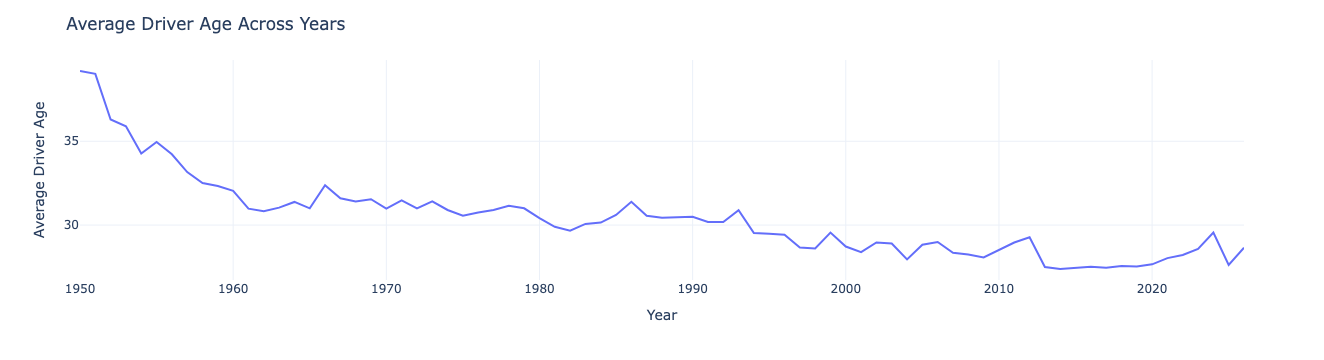

In [39]:
# average age of drivers across seasons
age_df = driver_results.groupby('year')['driver_age'].mean().round(2).reset_index()

fig = px.line(age_df, x='year', y='driver_age', template = "plotly_white")
fig.update_layout(
    title = "Average Driver Age Across Years",
    yaxis_title = "Average Driver Age",
    xaxis_title = "Year"
)
fig.show()

# Championships

In [40]:
# final races of each season
final_races = {}

for i in range(1950, 2026):
    # subset races for specified year
    df_year = df_races[df_races['year'] == i]

    # add race id to dictionary
    final_races[i] = df_year['raceId'].max()

## Driver Championships

In [41]:
# driver champions each year
driver_champs = (
    driver_results[['resultId', 'raceId', 'date', 'year', 'driverId', 'fullname', 'code', 'constructorId', 'name_constructor', 'driver_age', 'name_race', 'name_circuit', 'points_total', 'position_total', 'wins', 'round']]
    .loc[(driver_results['raceId'].isin(final_races.values())) & (driver_results['position_total'] == '1')]
    .sort_values(by='date', ascending=False)
)

# percent of races won by champion
driver_champs['percent_won'] = (driver_champs['wins'] / driver_champs['round'] * 100).round(2)

driver_champs.head()

,resultId,raceId,date,year,driverId,fullname,code,constructorId,name_constructor,driver_age,name_race,name_circuit,points_total,position_total,wins,round,percent_won
26751,27226,1168,2025-12-07,2025,846,Lando Norris,NOR,1,McLaren,26.07,Abu Dhabi Grand Prix,Yas Marina Circuit,423.0,1,7,24,29.17
26275,26750,1144,2024-12-08,2024,830,Max Verstappen,VER,9,Red Bull,27.19,Abu Dhabi Grand Prix,Yas Marina Circuit,437.0,1,9,24,37.50
25791,26266,1120,2023-11-26,2023,830,Max Verstappen,VER,9,Red Bull,26.15,Abu Dhabi Grand Prix,Yas Marina Circuit,575.0,1,19,22,86.36
25351,25826,1096,2022-11-20,2022,830,Max Verstappen,VER,9,Red Bull,25.14,Abu Dhabi Grand Prix,Yas Marina Circuit,454.0,1,15,22,68.18
24911,25386,1073,2021-12-12,2021,830,Max Verstappen,VER,9,Red Bull,24.20,Abu Dhabi Grand Prix,Yas Marina Circuit,395.5,1,10,22,45.45


### Which drivers have won the most championships?

In [9]:
# count number of championships
driver_champs['fullname'].value_counts().reset_index()

,fullname,count
0,Lewis Hamilton,7
1,Michael Schumacher,7
2,Juan Fangio,6
3,Alain Prost,4
4,Sebastian Vettel,4
5,Max Verstappen,4
6,Jackie Stewart,3
7,Nelson Piquet,3
8,Ayrton Senna,3
9,Jack Brabham,3


### On average, how many races or percentage of races do championship drivers win?

In [10]:
print('Average number of races won by champion: ', driver_champs['wins'].mean().round(2))
print('Average percentage of races won by champion: ', driver_champs['percent_won'].mean().round(2))

Average number of races won by champion:  6.46
Average percentage of races won by champion:  42.49


In [11]:
driver_champs[['wins', 'round', 'percent_won']].describe()

,wins,round,percent_won
count,74.000000,74.000000,74.000000
mean,6.459459,15.121622,42.490270
std,3.360484,4.341431,16.331748
min,1.000000,7.000000,6.250000
25%,4.000000,11.000000,31.250000
50%,6.000000,16.000000,42.265000
75%,8.750000,17.750000,52.940000
max,19.000000,24.000000,86.360000


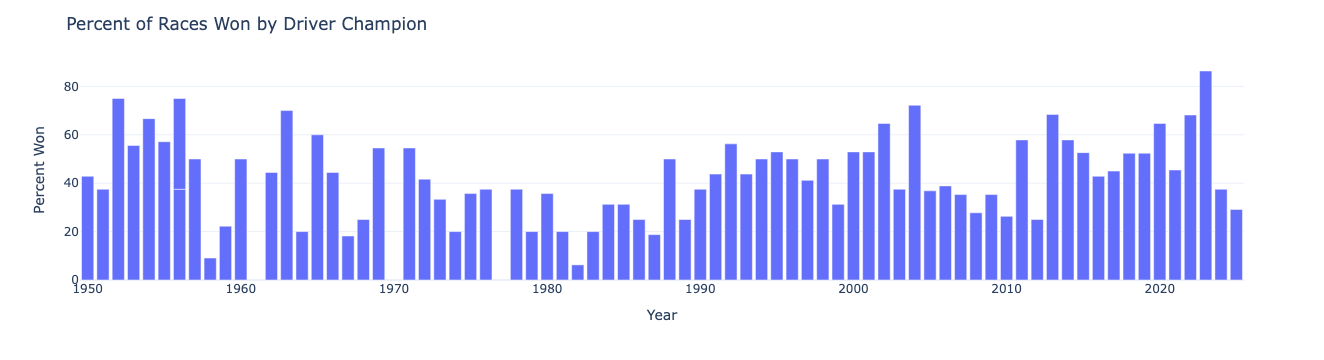

In [43]:
fig = px.bar(driver_champs, x='year', y='percent_won', template = "plotly_white")
fig.update_layout(
    title = "Percent of Races Won by Driver Champion",
    xaxis_title = "Year",
    yaxis_title = "Percent Won"
)
fig.show()

## Constructor Championships

In [13]:
constructor_results.head()

,constructorStandingsId,raceId,constructorId,points_total,wins,position,name_constructor,nationality,year,circuitId,name_race,date,time,round,name_circuit,location,country,points_race
0,1,18,1,14.0,1,1,McLaren,British,2008,1,Australian Grand Prix,2008-03-16,04:30:00,1,Albert Park Grand Prix Circuit,Melbourne,Australia,14.0
1,2,18,2,8.0,0,3,BMW Sauber,German,2008,1,Australian Grand Prix,2008-03-16,04:30:00,1,Albert Park Grand Prix Circuit,Melbourne,Australia,8.0
2,3,18,3,9.0,0,2,Williams,British,2008,1,Australian Grand Prix,2008-03-16,04:30:00,1,Albert Park Grand Prix Circuit,Melbourne,Australia,9.0
3,4,18,4,5.0,0,4,Renault,French,2008,1,Australian Grand Prix,2008-03-16,04:30:00,1,Albert Park Grand Prix Circuit,Melbourne,Australia,5.0
4,5,18,5,2.0,0,5,Toro Rosso,Italian,2008,1,Australian Grand Prix,2008-03-16,04:30:00,1,Albert Park Grand Prix Circuit,Melbourne,Australia,2.0


In [14]:
# constructor champions each year
constructor_champs = (
    constructor_results[['constructorStandingsId', 'year', 'constructorId', 'name_constructor', 'date','raceId', 'name_race', 'circuitId', 'name_circuit', 'points_total', 'position', 'wins', 'round']]
    .loc[(constructor_results['raceId'].isin(final_races.values())) & (constructor_results['position'] == '1')]
    .sort_values(by='date', ascending=False)
)

# proportion of races won by champion
constructor_champs['percent_won'] = (constructor_champs['wins'] / constructor_champs['round'] * 100).round(2)

constructor_champs.head()

,constructorStandingsId,year,constructorId,name_constructor,date,raceId,name_race,circuitId,name_circuit,points_total,position,wins,round,percent_won
12728,29213,2025,1,McLaren,2025-12-07,1168,Abu Dhabi Grand Prix,24,Yas Marina Circuit,833.0,1,14,24,58.33
12491,28976,2024,1,McLaren,2024-12-08,1144,Abu Dhabi Grand Prix,24,Yas Marina Circuit,666.0,1,6,24,25.00
12248,28703,2023,9,Red Bull,2023-11-26,1120,Abu Dhabi Grand Prix,24,Yas Marina Circuit,860.0,1,21,22,95.45
12037,28402,2022,9,Red Bull,2022-11-20,1096,Abu Dhabi Grand Prix,24,Yas Marina Circuit,759.0,1,17,22,77.27
11803,27923,2021,131,Mercedes,2021-12-12,1073,Abu Dhabi Grand Prix,24,Yas Marina Circuit,613.5,1,9,22,40.91


### Which teams have won the most championships?

In [15]:
# count number of championships
constructor_champs['name_constructor'].value_counts().reset_index()

,name_constructor,count
0,Ferrari,15
1,McLaren,10
2,Williams,9
3,Mercedes,8
4,Red Bull,6
5,Team Lotus,4
6,Renault,2
7,Brabham-Repco,2
8,Lotus-Climax,2
9,Cooper-Climax,2


## Champion Driver Team vs. Constructor Championship
### How often does the champion driver's team align with the constructor championships team?

In [54]:
# merge driver and constructor championships
champs = pd.merge(
    driver_champs[['year', 'date', 'fullname', 'code', 'name_constructor', 'driver_age', 'name_race', 'name_circuit', 'points_total', 'wins', 'percent_won']],
    constructor_champs[['year', 'date', 'name_constructor', 'name_race', 'name_circuit', 'points_total', 'wins', 'percent_won']],
    on=['year', 'date', 'name_race', 'name_circuit'],
    suffixes=('_driver', '_constructor')
)

# column for match between driver champion team and constructor champion
champs['team_match'] = champs['name_constructor_driver'] == champs['name_constructor_constructor']

champs.head()

,year,date,fullname,code,name_constructor_driver,driver_age,name_race,name_circuit,points_total_driver,wins_driver,percent_won_driver,name_constructor_constructor,points_total_constructor,wins_constructor,percent_won_constructor,team_match
0,2025,2025-12-07,Lando Norris,NOR,McLaren,26.07,Abu Dhabi Grand Prix,Yas Marina Circuit,423.0,7,29.17,McLaren,833.0,14,58.33,True
1,2024,2024-12-08,Max Verstappen,VER,Red Bull,27.19,Abu Dhabi Grand Prix,Yas Marina Circuit,437.0,9,37.50,McLaren,666.0,6,25.00,False
2,2023,2023-11-26,Max Verstappen,VER,Red Bull,26.15,Abu Dhabi Grand Prix,Yas Marina Circuit,575.0,19,86.36,Red Bull,860.0,21,95.45,True
3,2022,2022-11-20,Max Verstappen,VER,Red Bull,25.14,Abu Dhabi Grand Prix,Yas Marina Circuit,454.0,15,68.18,Red Bull,759.0,17,77.27,True
4,2021,2021-12-12,Max Verstappen,VER,Red Bull,24.20,Abu Dhabi Grand Prix,Yas Marina Circuit,395.5,10,45.45,Mercedes,613.5,9,40.91,False


In [63]:
# count number of times the teams match
print(f"{champs['team_match'].sum()} of the {champs.shape[0]} Driver and Constructor Champions are won by the same team")

53 of the 65 Driver and Constructor Champions are won by the same team


In [60]:
# show years when teams do not match
champs[champs['team_match'] == False]

,year,date,fullname,code,name_constructor_driver,driver_age,name_race,name_circuit,points_total_driver,wins_driver,percent_won_driver,name_constructor_constructor,points_total_constructor,wins_constructor,percent_won_constructor,team_match
1,2024,2024-12-08,Max Verstappen,VER,Red Bull,27.19,Abu Dhabi Grand Prix,Yas Marina Circuit,437.0,9,37.50,McLaren,666.0,6,25.00,False
4,2021,2021-12-12,Max Verstappen,VER,Red Bull,24.20,Abu Dhabi Grand Prix,Yas Marina Circuit,395.5,10,45.45,Mercedes,613.5,9,40.91,False
17,2008,2008-11-02,Lewis Hamilton,HAM,McLaren,23.82,Brazilian Grand Prix,Autódromo José Carlos Pace,98.0,5,27.78,Ferrari,172.0,8,44.44,False
26,1999,1999-10-31,Mika Häkkinen,\N,McLaren,31.09,Japanese Grand Prix,Suzuka Circuit,76.0,5,31.25,Ferrari,128.0,6,37.50,False
31,1994,1994-11-13,Michael Schumacher,MSC,Benetton,25.86,Australian Grand Prix,Adelaide Street Circuit,92.0,8,50.00,Williams,118.0,7,43.75,False
39,1986,1986-10-26,Alain Prost,\N,McLaren,31.67,Australian Grand Prix,Adelaide Street Circuit,72.0,4,25.00,Williams,141.0,9,56.25,False
42,1983,1983-10-15,Nelson Piquet,\N,Brabham,31.16,South African Grand Prix,Kyalami,59.0,3,20.00,Ferrari,89.0,4,26.67,False
43,1982,1982-09-25,Keke Rosberg,\N,Williams,33.80,Caesars Palace Grand Prix,Las Vegas Street Circuit,44.0,1,6.25,Ferrari,74.0,3,18.75,False
44,1981,1981-10-17,Nelson Piquet,\N,Brabham,29.17,Caesars Palace Grand Prix,Las Vegas Street Circuit,50.0,3,20.00,Williams,95.0,4,26.67,False
48,1976,1976-10-24,James Hunt,\N,McLaren,29.16,Japanese Grand Prix,Fuji Speedway,69.0,6,37.50,Ferrari,83.0,6,37.50,False


# Points Over The Season

Visualization of points adapted from https://docs.fastf1.dev/gen_modules/examples_gallery/standings/plot_season_summary.html

In [87]:
def season_points(df, year, drivers=True, colors='YlGnBu'):
    """
    Plot championships points over time for drivers or teams.

    df: DataFrame containing at least ['year', 'name_race', 'round', 'points_race', 'points_total'] as well as 'code' or 'name_constructor' for drivers and constructors, respectively
    year: integer indicating year of selected season
    drivers: boolean indicating figure for driver or constructor data
    colors: colorscale for heatmap, default='YlGnBu'
    """
    season_df = df[df['year'] == year].copy()

    # simplify race names by removing 'Grand Prix'
    season_df['name_race'] = season_df['name_race'].str[:-11]

    if drivers:
        heatmap_df = season_df.pivot_table(
            index='code',
            columns='name_race',
            values='points_race',
            aggfunc='mean'
        )
        total_df = season_df.groupby('code')['points_race'].sum().to_frame(name='total_points').sort_values(by='total_points', ascending=True)
    else:
        heatmap_df = season_df.pivot_table(
            index='name_constructor',
            columns='name_race',
            values='points_race',
            aggfunc='mean'
        )
        total_df = season_df.groupby('name_constructor')['points_race'].sum().to_frame(name='total_points').sort_values(by='total_points', ascending=True)

    # order of races
    race_order = season_df[['name_race', 'round']].drop_duplicates().sort_values('round')
    ordered_races = race_order['name_race'].tolist()

    # reorder races
    heatmap_df = heatmap_df[ordered_races]

    # reorder drivers or teams based on total points
    heatmap_df = heatmap_df.loc[total_df.index]

    # heatmap of race points
    fig = fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.85, 0.15],
        subplot_titles=(f'{year} Season Summary', 'Total Points'),
    )

    fig.add_trace(go.Heatmap(
        z = heatmap_df.values,
        x = heatmap_df.columns,
        y = heatmap_df.index,
        colorscale = colors,
        showscale = False,
        text = heatmap_df.fillna('').values,
        texttemplate = '%{text}',
        hovertemplate=(
        "Driver/Team: %{y}<br>"
        "Race: %{x}<br>"
        "Points: %{z}<extra></extra>"),
    ),
        row = 1, col = 1
    )

    # total points
    fig.add_trace(go.Heatmap(
        z = total_df.values,
        x = total_df.columns,
        y = total_df.index,
        colorscale = colors,
        showscale = False,
        text = total_df.values,
        texttemplate = '%{text}',
        hovertemplate=(
        "Name: %{y}<br>"
        "Total Points: %{z}<extra></extra>")
    ),
        row = 1, col = 2
    )

    fig.update_layout(
        title=f"{year} Season Points",
        template='simple_white', 
        plot_bgcolor='black',
        width=900,
        height=700,
    )

    if drivers != True:
        # remove y axis labels to declutter plot
        fig.update_yaxes(showticklabels=False, title_text='', row=1, col=2)

    fig.show()

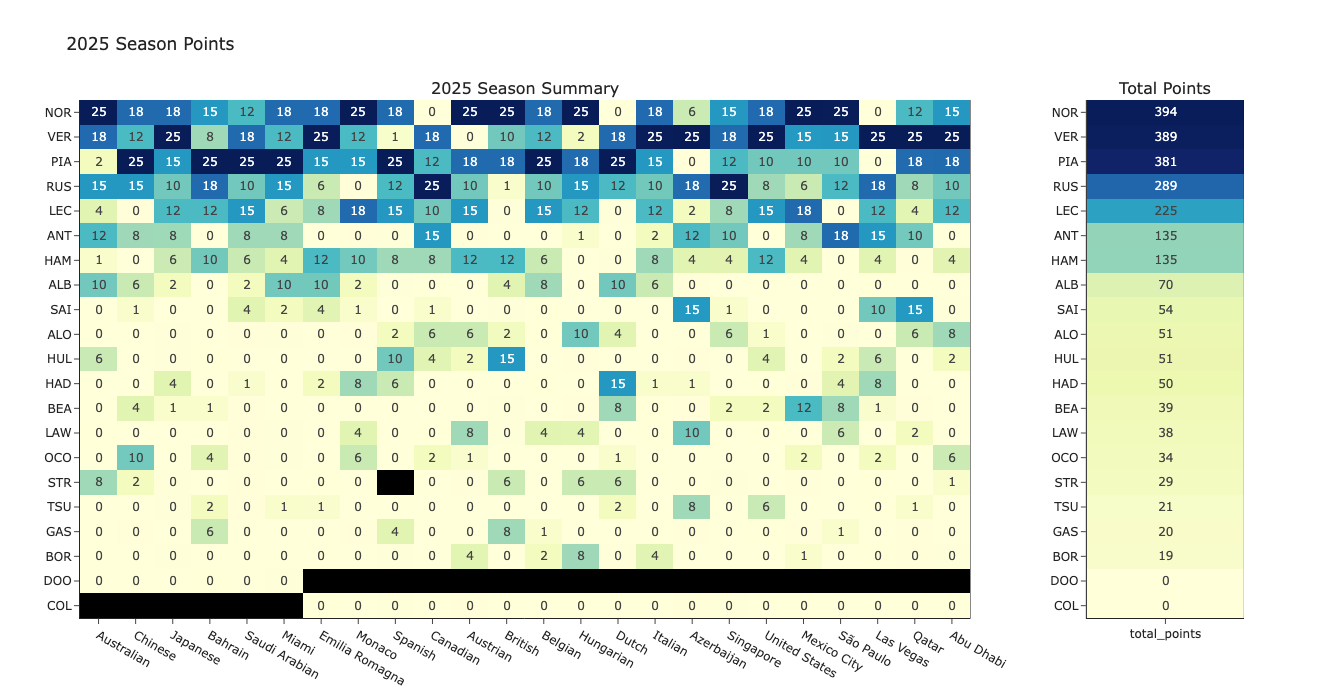

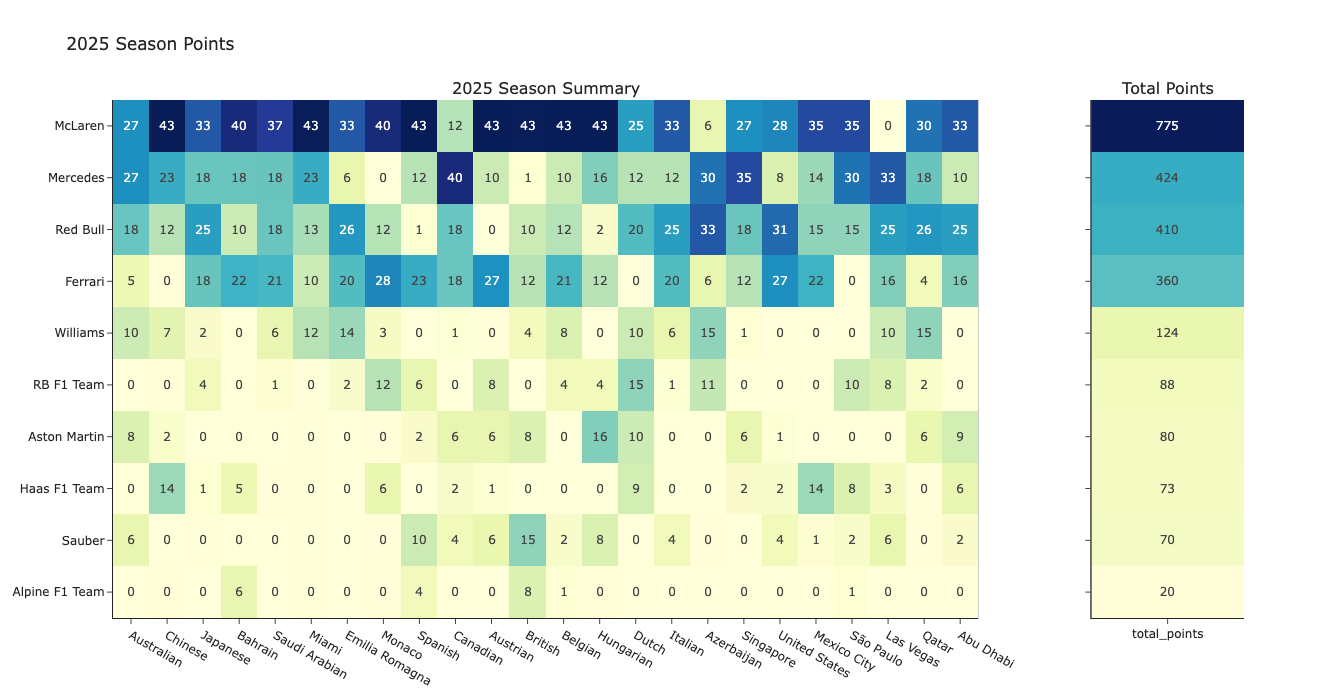

In [69]:
# figures for 2025 season
season_points(driver_results, 2025)
season_points(constructor_results, 2025, drivers=False)

# Individual Drivers

In [19]:
def driver_heatmap(df, driver_name, zero_col='lightgrey', first_col='red', sec_col='gold', third_col='orange', width=700, height=700):
    """
    Plots race results over time for a specific driver as a heatmap.

    df: DataFrame containing at least ['fullname', 'year', 'name_circuit', 'position_race']
    driver_name: string of the driver's full name
    """
    # check that driver is in df
    if (df['fullname'] == driver_name).any():
        # filter for specified driver
        driver_df = df[df['fullname'] == driver_name].copy()
    else:
        return "Driver not found. Check name and/or dataframe."

    # select columns
    driver_df = driver_df[['name_circuit', 'year', 'position_race']]

    # position variable
    driver_df['position_race'] = (driver_df['position_race'].replace(r'\N', pd.NA)).astype('Int64')

    # podium
    driver_df['podium'] = driver_df['position_race'].apply(lambda x: x if x in [1,2,3] else 0)

    # colorscale
    my_colorscale = [
        [0, zero_col],
        [0.33, first_col],
        [0.66, sec_col],
        [1, third_col]
    ]

    heatmap_df = driver_df.pivot_table(
        index='name_circuit',
        columns='year',
        values='podium',
        aggfunc='max'
    )

    # adjust range of years to account for a driver's years off if any
    years_range = np.arange(driver_df['year'].min(), driver_df['year'].max() + 1)
    heatmap_df = heatmap_df.reindex(columns=years_range)

    fig = px.imshow(heatmap_df,
                labels=dict(x='year', y='circuit'),
                color_continuous_scale= my_colorscale,
                text_auto=True, 
                aspect='auto'
               )

    fig.update_xaxes(
        tickmode='array',
        tickvals=heatmap_df.columns.astype(str),
        tickangle=45
    )

    fig.update_layout(
        title=f"{driver_name} Podium Results by Circuit and Year",
        template='simple_white', 
        plot_bgcolor='black',
        width=width,
        height=height,
    )
    
    fig.show()

## Max Verstappen

In [21]:
driver_heatmap(driver_results, 'Max Verstappen')

## Lewis Hamilton

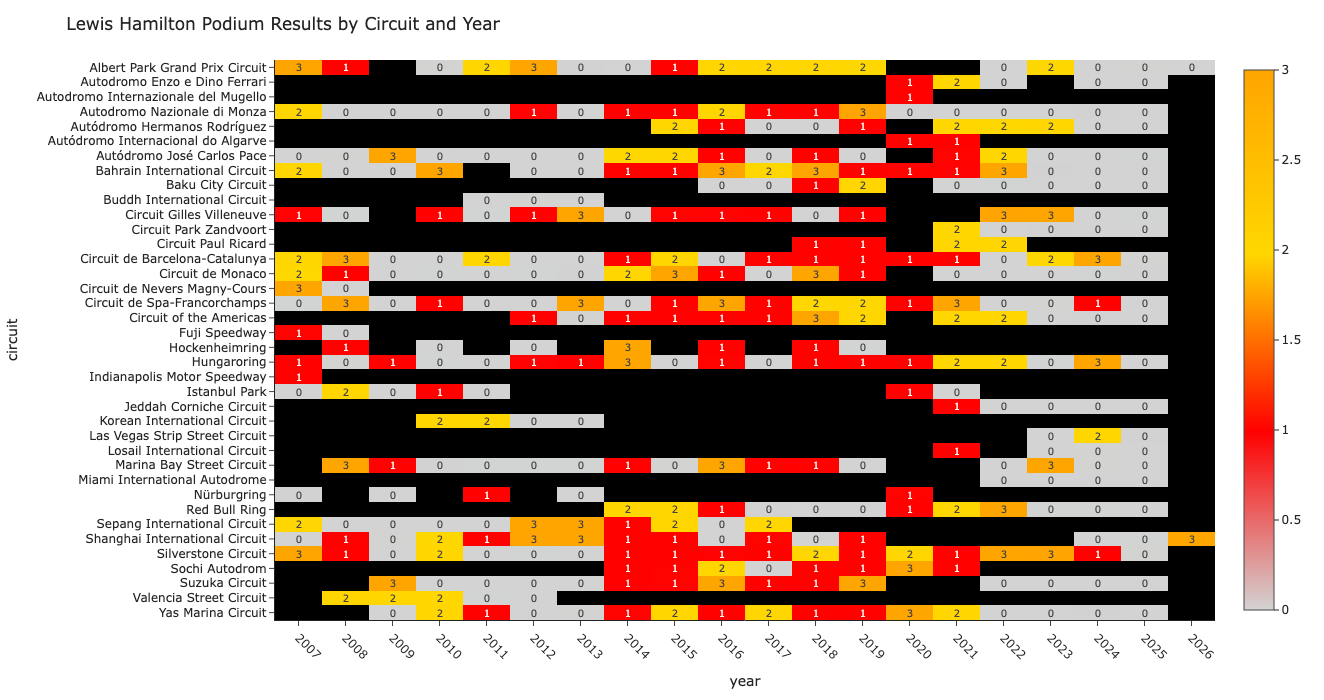

In [46]:
driver_heatmap(driver_results, 'Lewis Hamilton')

## Michael Schumacher

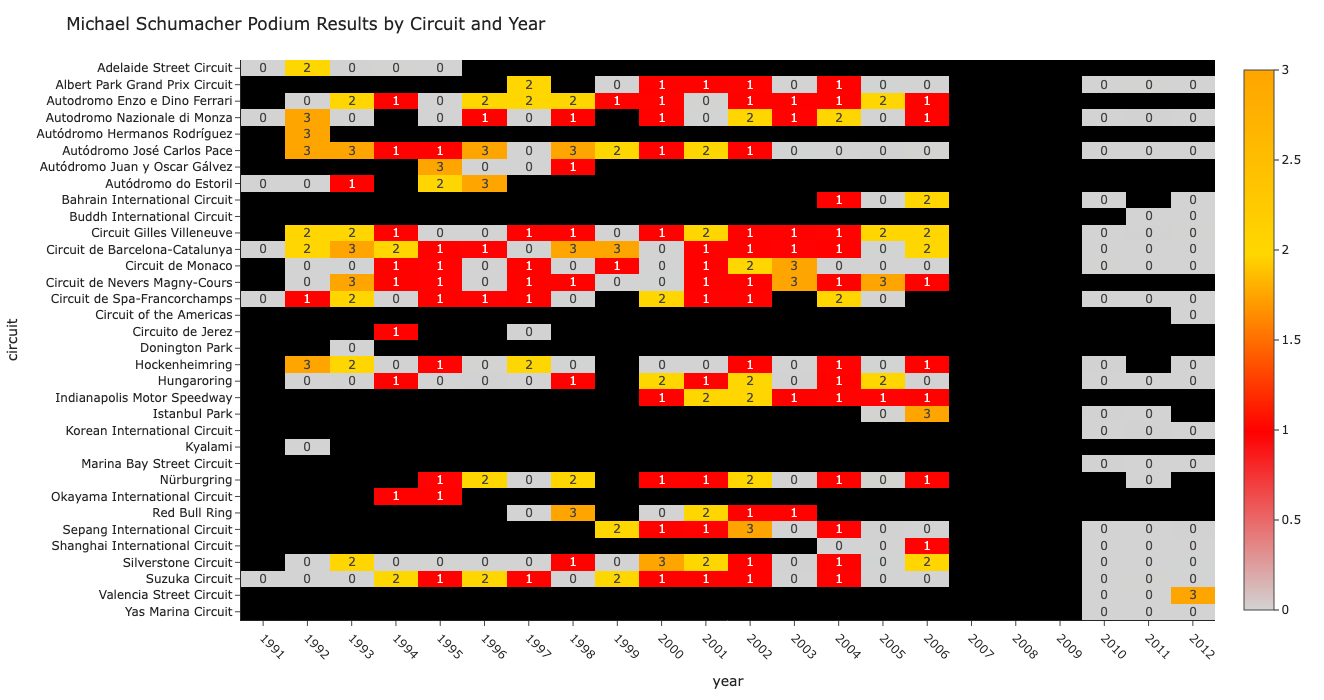

In [45]:
driver_heatmap(driver_results, 'Michael Schumacher')

## Fernando Alonso

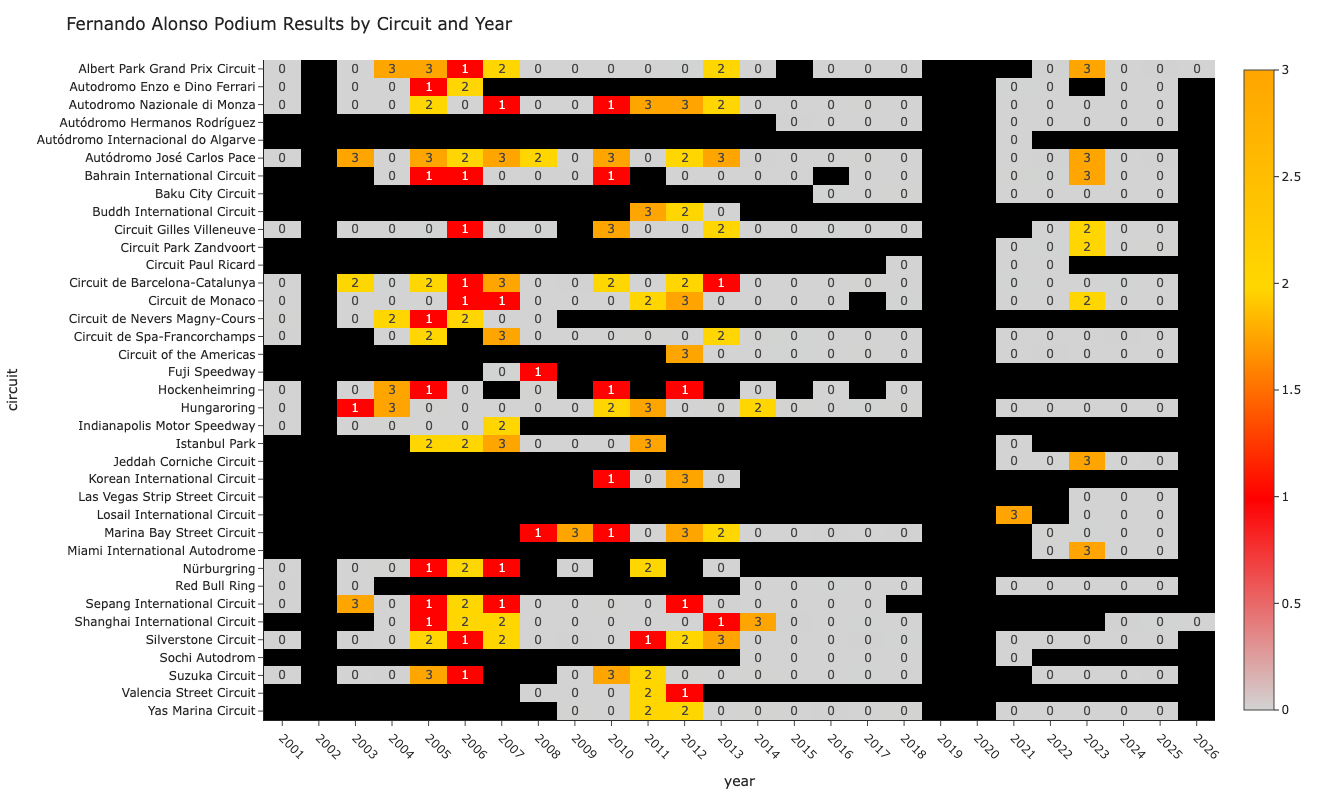

In [44]:
driver_heatmap(driver_results, 'Fernando Alonso', width=800, height=800)

## Oscar Piastri

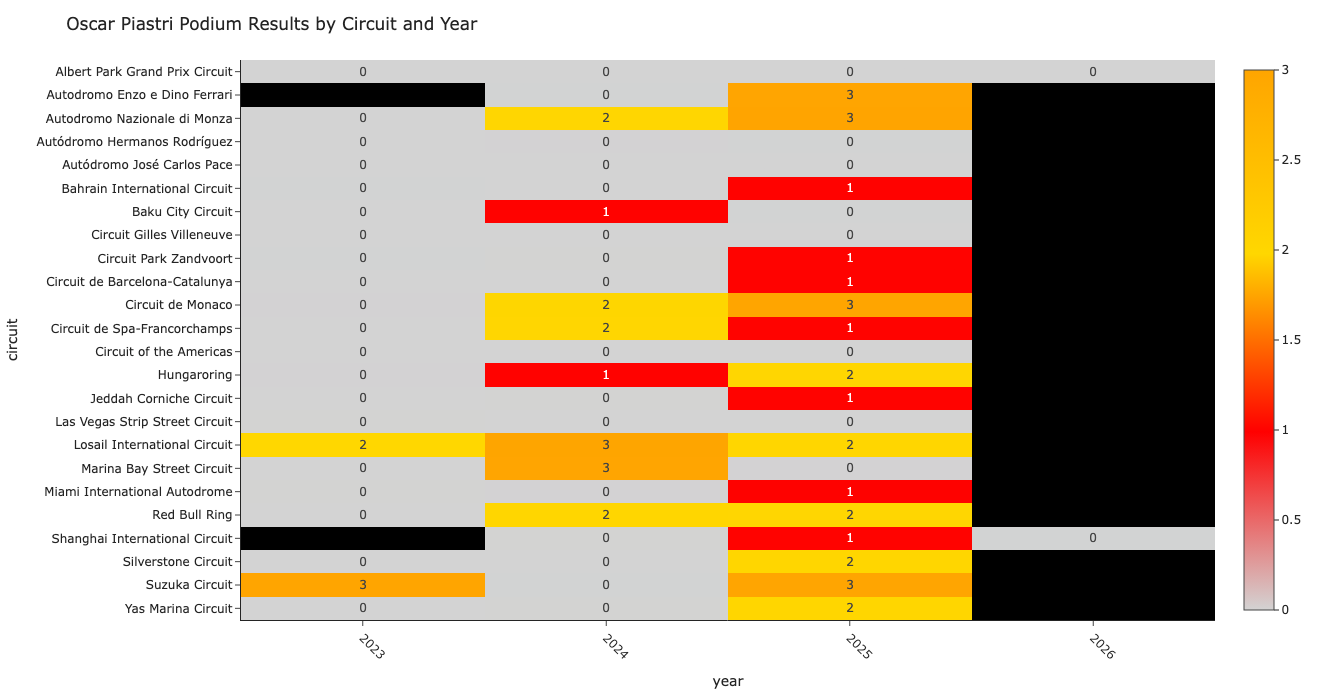

In [72]:
driver_heatmap(driver_results, 'Oscar Piastri')

## Kimi Antonelli

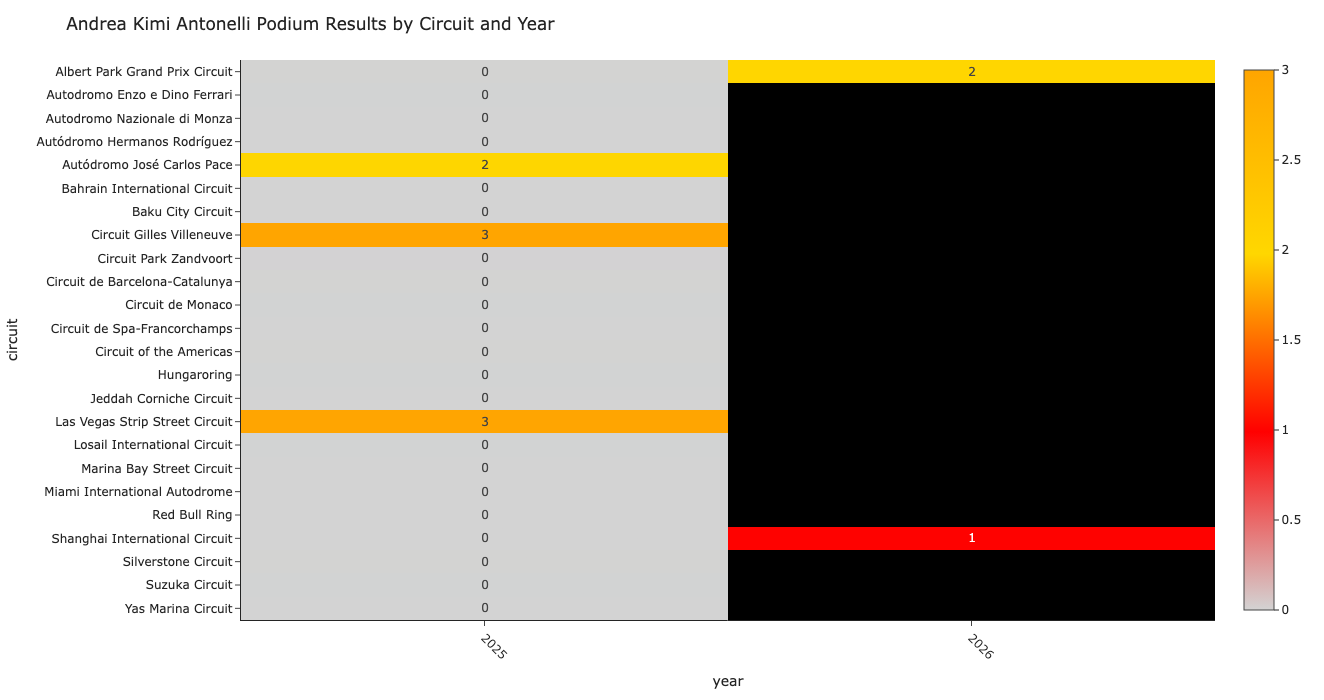

In [33]:
driver_heatmap(driver_results, 'Andrea Kimi Antonelli')